# Customer Segmentation: RFM Analysis and K-Means Clustering

This notebook presents a complete retail customer segmentation analysis using RFM scoring and K-Means clustering. The goal is to identify high-value, loyal, and at-risk customer groups for targeted marketing and retention strategies.

## 1. Import Required Libraries

Import the libraries needed for data loading, visualization, and machine learning.

In [10]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn openpyxl
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


## 2. Load and Inspect Data

Load the dataset into a DataFrame, inspect its shape, and preview sample rows.

In [11]:
DATA_PATH = "/Users/sidharthmalik/Desktop/Projects/Customer Segmentation using RFM Analysis & K-Means Clustering/online_retail_II.xlsx"
df = pd.read_excel(DATA_PATH, engine="openpyxl")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Data Cleaning and Preprocessing

Clean missing values, fix formats, and create the core `TotalPrice` feature used for RFM analysis.

In [12]:
df_clean = df.copy()
df_clean = df_clean.dropna(subset=["Invoice", "StockCode", "Customer ID", "Description"])
df_clean = df_clean[~df_clean["Invoice"].astype(str).str.startswith("C")]
df_clean = df_clean[df_clean["Quantity"] > 0]
df_clean = df_clean[df_clean["Price"] > 0]
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")
df_clean = df_clean.dropna(subset=["InvoiceDate"])
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["Price"]
print("Cleaned dataset shape:", df_clean.shape)
df_clean.head()

Cleaned dataset shape: (407664, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## 4. Exploratory Data Analysis

Explore customer behavior, transaction volume, country distribution, and top products.

Unique customers: 4312
Unique invoices: 19213
Countries: 37


/var/folders/lh/cqy3xxtx5t7925cwmtnw7gbr0000gn/T/ipykernel_51039/1522714920.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


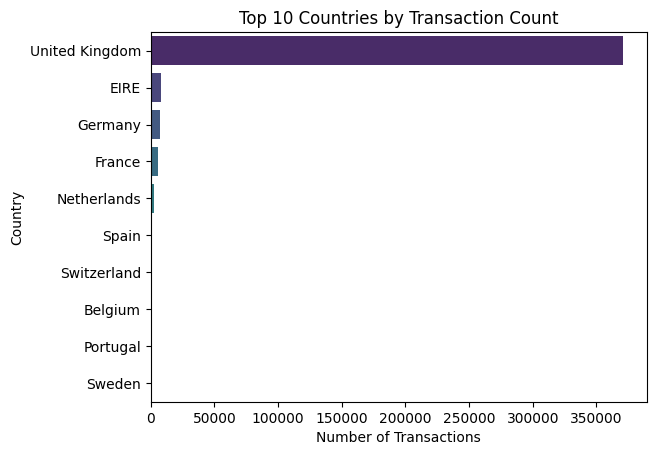

/var/folders/lh/cqy3xxtx5t7925cwmtnw7gbr0000gn/T/ipykernel_51039/1522714920.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="magma")


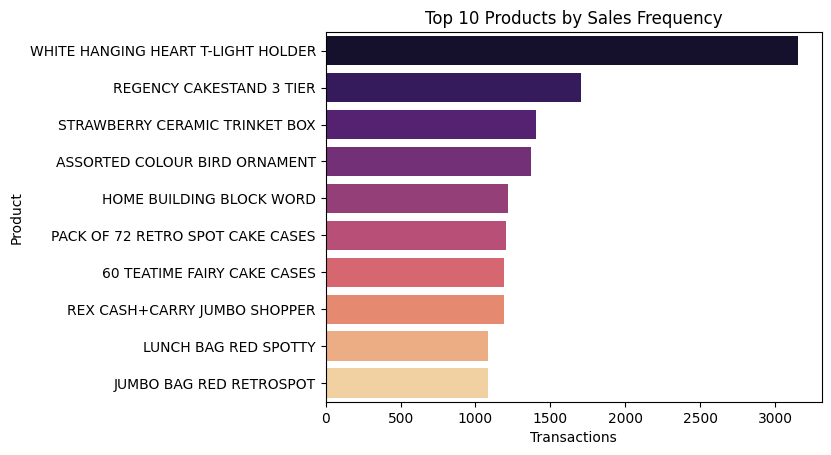

In [13]:
print("Unique customers:", df_clean["Customer ID"].nunique())
print("Unique invoices:", df_clean["Invoice"].nunique())
print("Countries:", df_clean["Country"].nunique())

top_countries = df_clean["Country"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 10 Countries by Transaction Count")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.show()

top_products = df_clean["Description"].value_counts().head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette="magma")
plt.title("Top 10 Products by Sales Frequency")
plt.xlabel("Transactions")
plt.ylabel("Product")
plt.show()

## 5. Feature Engineering

Create RFM features for each customer and compute segment scores.

In [14]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = df_clean.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "TotalPrice": "sum"
})
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm = rfm[rfm["Monetary"] > 0]
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2048.238236
std,96.860633,8.170213,8914.481280
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.987500
50%,53.000000,2.000000,706.020000
75%,136.000000,5.000000,1723.142500
max,374.000000,205.000000,349164.350000


In [15]:
rfm["RScore"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["FScore"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["MScore"] = pd.qcut(rfm["Monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFMScore"] = rfm["RScore"].astype(str) + rfm["FScore"].astype(str) + rfm["MScore"].astype(str)
rfm["RFMTotal"] = rfm[["RScore", "FScore", "MScore"]].sum(axis=1)
rfm.head()

,Recency,Frequency,Monetary,RScore,FScore,MScore,RFMScore,RFMTotal
Customer ID,,,,,,,,
12346.0,165,11,372.86,1,4,2,142,7
12347.0,3,2,1323.32,4,2,3,423,9
12348.0,74,1,222.16,2,1,1,211,4
12349.0,43,3,2671.14,3,3,4,334,10
12351.0,11,1,300.93,4,1,1,411,6


## 6. Split Data and Prepare Pipelines

Prepare a preprocessing pipeline and split features for cluster validation.

In [16]:
features = rfm[["Recency", "Frequency", "Monetary"]].copy()
X_train, X_test = train_test_split(features, test_size=0.25, random_state=42)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
])
X_train_scaled = pipeline.fit_transform(X_train)
X_test_scaled = pipeline.transform(X_test)
print("Training set size:", X_train.shape)
print("Validation set size:", X_test.shape)


Training set size: (3234, 3)
Validation set size: (1078, 3)


## 7. Train Machine Learning Models

Train K-Means clustering and visualize the elbow method for selecting `k`.

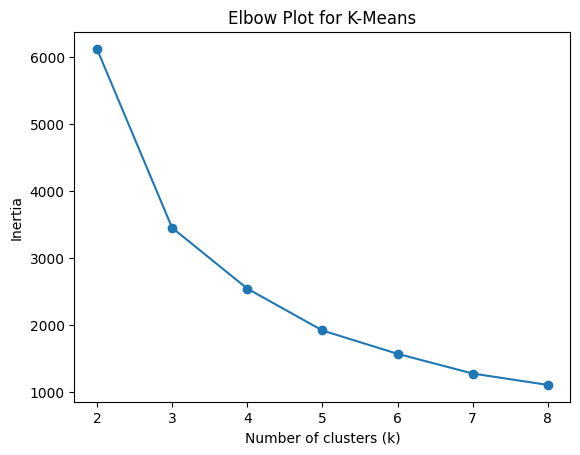

Chosen number of clusters: 4
Silhouette score (train): 0.6176928861397856


In [17]:
inertias = []
K = range(2, 9)
for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_train_scaled)
    inertias.append(model.inertia_)

plt.plot(K, inertias, marker="o")
plt.title("Elbow Plot for K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_train_scaled)
print("Chosen number of clusters:", best_k)
print("Silhouette score (train):", silhouette_score(X_train_scaled, cluster_labels))


## 8. Evaluate Model Performance

Assign cluster labels to the full customer dataset and profile each segment.

In [18]:
rfm_scaled = pipeline.transform(features)
rfm["Cluster"] = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(rfm_scaled)
cluster_profile = rfm.groupby("Cluster").agg({
    "Recency": ["mean", "median"],
    "Frequency": ["mean", "median"],
    "Monetary": ["mean", "median"],
    "RFMTotal": ["mean", "median"],
}).round(1)
cluster_profile


Recency        Frequency         Monetary           RFMTotal       
           mean median      mean median      mean    median     mean median
Cluster                                                                    
0          42.8   32.0       4.5    3.0    1797.1     934.0      8.4    9.0
1           5.6    7.0     113.6   94.0  215543.7  196566.7     12.0   12.0
2         242.7  233.0       1.7    1.0     595.8     306.3      4.5    4.0
3          16.0    5.0      52.0   40.0   28935.3   20329.7     11.8   12.0

## 9. Save Results and Export Artifacts

Save the segmented customer data and cluster profile summary to the output folder.

In [19]:
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)
rfm.to_csv(os.path.join(output_dir, "rfm_segments.csv"), index=True)
cluster_profile.to_csv(os.path.join(output_dir, "cluster_profile.csv"))
print("Saved segmented customer data and cluster summaries to the output folder.")


Saved segmented customer data and cluster summaries to the output folder.
